In [1]:
# Find exact dataset path on Kaggle

import os

print("── /kaggle/input contents ──")
for folder in os.listdir('/kaggle/input'):
    print(f"  {folder}/")
    for f in os.listdir(f'/kaggle/input/{folder}'):
        print(f"    {f}")

── /kaggle/input contents ──
  datasets/
    deetchanadharani


In [2]:
# Dig deeper into the folder structure

import os

def show_tree(path, level=0):
    for item in os.listdir(path):
        full = os.path.join(path, item)
        print("  " * level + item)
        if os.path.isdir(full) and level < 4:
            show_tree(full, level + 1)

show_tree('/kaggle/input/datasets')

deetchanadharani
  leukemia-datasets
    ALL_IDB
      ALL_IDB
        Leukemia
        Normal
    C-NMC_Leukemia
      fold_0
        fold_0
      fold_1
        fold_1
      fold_2
        fold_2


In [3]:
# COMPLETE MODEL 2 PIPELINE — KAGGLE FIXED VERSION

import subprocess
subprocess.run(['pip', 'install', 'timm', '-q'])

import os, copy, random, shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cmap
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score)
from sklearn.utils.class_weight import compute_class_weight
import timm
from tqdm import tqdm
from pathlib import Path

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


In [4]:

# ══════════════════════════════════════════════════════════
# STEP 1 — ORGANISE INTO train/test FOLDERS
# ══════════════════════════════════════════════════════════
BASE = '/kaggle/input/datasets/deetchanadharani/leukemia-datasets'
CNMC   = f'{BASE}/C-NMC_Leukemia'
ALLIDB = f'{BASE}/ALL_IDB/ALL_IDB'

print("\nOrganising dataset...")
for split in ['train', 'test']:
    for cls in ['ALL', 'HEM']:
        Path(f'/kaggle/working/data/{split}/{cls}').mkdir(parents=True, exist_ok=True)

def copy_images(src, dst):
    if not os.path.exists(src):
        print(f"  WARNING: {src} not found, skipping")
        return 0
    count = 0
    for f in os.listdir(src):
        if f.lower().endswith(('.jpg','.jpeg','.png','.bmp')):
            shutil.copy(os.path.join(src, f), dst)
            count += 1
    return count

# C-NMC: fold_0 + fold_1 → train, fold_2 → test
for fold in ['fold_0', 'fold_1']:
    n = copy_images(f'{CNMC}/{fold}/{fold}/all', '/kaggle/working/data/train/ALL')
    print(f"  {fold} ALL → train: {n}")
    n = copy_images(f'{CNMC}/{fold}/{fold}/hem', '/kaggle/working/data/train/HEM')
    print(f"  {fold} HEM → train: {n}")

n = copy_images(f'{CNMC}/fold_2/fold_2/all', '/kaggle/working/data/test/ALL')
print(f"  fold_2 ALL → test: {n}")
n = copy_images(f'{CNMC}/fold_2/fold_2/hem', '/kaggle/working/data/test/HEM')
print(f"  fold_2 HEM → test: {n}")

# ALL_IDB
for sub in ['L1', 'L2', 'L3']:
    n = copy_images(f'{ALLIDB}/Leukemia/{sub}', '/kaggle/working/data/train/ALL')
    print(f"  ALL_IDB {sub} → train/ALL: {n}")
n = copy_images(f'{ALLIDB}/Normal/hem', '/kaggle/working/data/train/HEM')
print(f"  ALL_IDB Normal → train/HEM: {n}")

print("\nDataset summary:")
for split in ['train', 'test']:
    for cls in ['ALL', 'HEM']:
        count = len(os.listdir(f'/kaggle/working/data/{split}/{cls}'))
        print(f"  data/{split}/{cls}/  ← {count} images")


Organising dataset...
  fold_0 ALL → train: 2397
  fold_0 HEM → train: 1130
  fold_1 ALL → train: 2418
  fold_1 HEM → train: 1163
  fold_2 ALL → test: 2457
  fold_2 HEM → test: 1096
  ALL_IDB L1 → train/ALL: 50
  ALL_IDB L2 → train/ALL: 50
  ALL_IDB L3 → train/ALL: 38
  ALL_IDB Normal → train/HEM: 1130

Dataset summary:
  data/train/ALL/  ← 4946 images
  data/train/HEM/  ← 2293 images
  data/test/ALL/  ← 2457 images
  data/test/HEM/  ← 1096 images


In [5]:
# ══════════════════════════════════════════════════════════
# STEP 2 — DATA LOADERS
# ══════════════════════════════════════════════════════════
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

full_train = ImageFolder('/kaggle/working/data/train', transform=train_tf)
test_ds    = ImageFolder('/kaggle/working/data/test',  transform=val_tf)

val_size   = int(0.15 * len(full_train))
train_size = len(full_train) - val_size
train_ds, val_ds = random_split(full_train, [train_size, val_size],
                    generator=torch.Generator().manual_seed(SEED))
val_ds_copy = copy.deepcopy(full_train)
val_ds_copy.transform = val_tf
val_ds.dataset = val_ds_copy

labels_array = np.array(full_train.targets)
cw  = compute_class_weight('balanced', classes=np.unique(labels_array), y=labels_array)
cw_tensor = torch.tensor(cw, dtype=torch.float).to(DEVICE)
print(f"\nClass weights: ALL={cw[0]:.3f}, HEM={cw[1]:.3f}")

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True)



Class weights: ALL=0.732, HEM=1.578


In [6]:
# ══════════════════════════════════════════════════════════
# STEP 3 — PURE ViT MODEL
# ══════════════════════════════════════════════════════════
class PureViT(nn.Module):
    def __init__(self, num_classes=2, dropout=0.3):
        super().__init__()
        self.vit = timm.create_model('vit_base_patch16_224',
                                     pretrained=True, num_classes=0)
        self.head = nn.Sequential(
            nn.LayerNorm(768),
            nn.Dropout(dropout),
            nn.Linear(768, 256),
            nn.GELU(),
            nn.Dropout(dropout/2),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.head(self.vit(x))

    def extract_features(self, x):
        with torch.no_grad():
            return self.vit(x)

model = PureViT().to(DEVICE)
print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]


Model parameters: 85,997,570


In [7]:
# ══════════════════════════════════════════════════════════
# STEP 4 — TRAIN ViT
# ══════════════════════════════════════════════════════════
criterion = nn.CrossEntropyLoss(weight=cw_tensor, label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            correct += (model(imgs).argmax(1) == labels).sum().item()
            total   += labels.size(0)
    return correct / total

best_acc, best_state = 0.0, None
train_history = []

print("\nStarting ViT fine-tuning (10 epochs)...\n")
for epoch in range(1, 21):
    model.train()
    running_loss = correct = total = 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/20"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct += (logits.detach().argmax(1) == labels).sum().item()
        total   += labels.size(0)

    train_acc = correct / total
    val_acc   = evaluate(model, val_loader)
    scheduler.step()
    train_history.append((train_acc, val_acc))

    print(f"Epoch {epoch:02d} | Loss: {running_loss/total:.4f} | "
          f"Train: {train_acc*100:.2f}% | Val: {val_acc*100:.2f}%")

    if val_acc > best_acc:
        best_acc   = val_acc
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, '/kaggle/working/best_vit_model2.pth')
        print(f"  ✓ Best saved (val={best_acc*100:.2f}%)")

model.load_state_dict(best_state)
print(f"\nViT done! Best val accuracy: {best_acc*100:.2f}%")


Starting ViT fine-tuning (10 epochs)...



Epoch 1/20: 100%|██████████| 193/193 [03:46<00:00,  1.17s/it]


Epoch 01 | Loss: 0.5182 | Train: 79.87% | Val: 89.86%
  ✓ Best saved (val=89.86%)


Epoch 2/20: 100%|██████████| 193/193 [03:58<00:00,  1.23s/it]


Epoch 02 | Loss: 0.4377 | Train: 87.08% | Val: 92.35%
  ✓ Best saved (val=92.35%)


...

Epoch 18 | Loss: 0.3281 | Train: 94.90% | Val: 94.84%


Epoch 19/20: 100%|██████████| 193/193 [03:58<00:00,  1.23s/it]


Epoch 19 | Loss: 0.3273 | Train: 94.57% | Val: 96.22%


Epoch 20/20: 100%|██████████| 193/193 [03:58<00:00,  1.24s/it]


Epoch 20 | Loss: 0.3283 | Train: 94.52% | Val: 93.73%

ViT done! Best val accuracy: 97.14%


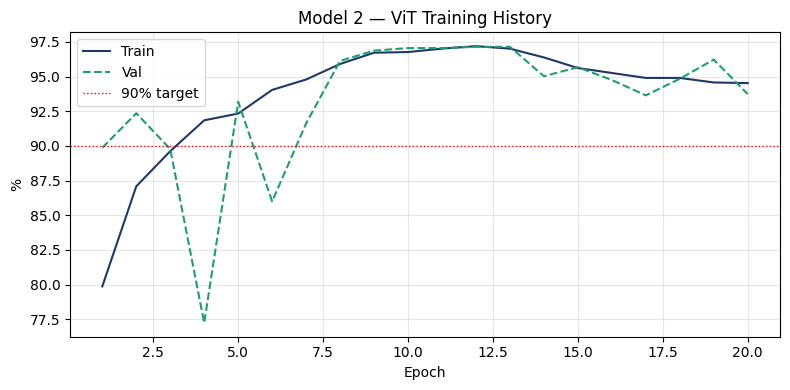

In [8]:
# Training plot
fig, ax = plt.subplots(figsize=(8, 4))
epochs_range = range(1, len(train_history)+1)
ax.plot(epochs_range, [h[0]*100 for h in train_history], label='Train', color='#1F3864')
ax.plot(epochs_range, [h[1]*100 for h in train_history], label='Val', color='#1D9E75', linestyle='--')
ax.axhline(90, color='red', linestyle=':', linewidth=1, label='90% target')
ax.set_title('Model 2 — ViT Training History')
ax.set_xlabel('Epoch'); ax.set_ylabel('%')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/vit_training_history.png', dpi=150)
plt.show()

In [9]:
# ══════════════════════════════════════════════════════════
# STEP 5 — EXTRACT ViT FEATURES
# ══════════════════════════════════════════════════════════
print("\nExtracting ViT features...")

def extract_features(model, loader):
    model.eval()
    feats, labs = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Extracting"):
            feats.append(model.extract_features(imgs.to(DEVICE)).cpu().numpy())
            labs.append(labels.numpy())
    return np.vstack(feats), np.concatenate(labs)

X_train, y_train = extract_features(model, train_loader)
X_val,   y_val   = extract_features(model, val_loader)
X_test,  y_test  = extract_features(model, test_loader)
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")



Extracting ViT features...


Extracting: 100%|██████████| 112/112 [00:46<00:00,  2.38it/s]

Train: (6154, 768) | Val: (1085, 768) | Test: (3553, 768)


PSO start — initial best: 97.60%
  Iter 01/10 | Best: 97.60% | Features: 380
  Iter 02/10 | Best: 97.60% | Features: 380
  Iter 03/10 | Best: 97.79% | Features: 364
  Iter 04/10 | Best: 97.79% | Features: 364
  Iter 05/10 | Best: 97.79% | Features: 364
  Iter 06/10 | Best: 97.79% | Features: 364
  Iter 07/10 | Best: 97.79% | Features: 364
  Iter 08/10 | Best: 97.79% | Features: 364
  Iter 09/10 | Best: 97.79% | Features: 364
  Iter 10/10 | Best: 97.97% | Features: 377

PSO done — 377 features, best: 97.97%


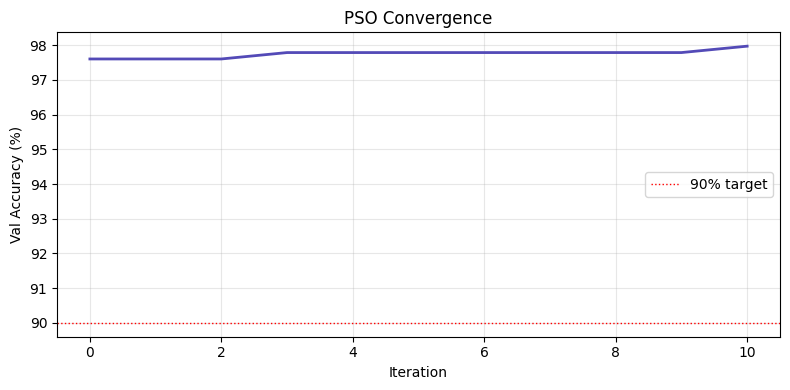


PSO complete!
Best fitness  : 97.97%
Features kept : 377 / 768


In [10]:
# PSO COMPLETE — REDUCED VERSION

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

class PSO:
    def __init__(self, X_tr, y_tr, X_v, y_v,
                 n_particles=20, n_iters=10,
                 w=0.6, c1=1.5, c2=1.5, min_feat=50):
        self.X_tr, self.y_tr = X_tr, y_tr
        self.X_v,  self.y_v  = X_v,  y_v
        self.n_feat      = X_tr.shape[1]
        self.n_particles = n_particles
        self.n_iters     = n_iters
        self.w, self.c1, self.c2 = w, c1, c2
        self.min_feat    = min_feat

    def _sigmoid(self, v):
        return 1.0 / (1.0 + np.exp(-np.clip(v, -20, 20)))

    def _fitness(self, mask):
        idx = np.where(mask == 1)[0]
        if len(idx) < self.min_feat:
            return 0.0
        clf = MLPClassifier(hidden_layer_sizes=(256, 128),
                            max_iter=300, random_state=42,
                            early_stopping=True, n_iter_no_change=15)
        clf.fit(self.X_tr[:, idx], self.y_tr)
        return accuracy_score(self.y_v, clf.predict(self.X_v[:, idx]))

    def run(self):
        n, d = self.n_particles, self.n_feat
        pos  = (np.random.rand(n, d) > 0.5).astype(float)
        vel  = np.random.uniform(-1, 1, (n, d))
        pbest_pos   = pos.copy()
        pbest_score = np.array([self._fitness(p) for p in pos])
        g_idx       = pbest_score.argmax()
        gbest_pos   = pbest_pos[g_idx].copy()
        gbest_score = pbest_score[g_idx]
        print(f"PSO start — initial best: {gbest_score*100:.2f}%")
        history = [gbest_score]

        for it in range(1, self.n_iters + 1):
            r1 = np.random.rand(n, d)
            r2 = np.random.rand(n, d)
            vel = (self.w * vel
                   + self.c1 * r1 * (pbest_pos - pos)
                   + self.c2 * r2 * (gbest_pos - pos))
            pos = (np.random.rand(n, d) < self._sigmoid(vel)).astype(float)
            scores = np.array([self._fitness(p) for p in pos])
            improved = scores > pbest_score
            pbest_pos[improved]   = pos[improved]
            pbest_score[improved] = scores[improved]
            if pbest_score.max() > gbest_score:
                gbest_score = pbest_score.max()
                gbest_pos   = pbest_pos[pbest_score.argmax()].copy()
            history.append(gbest_score)
            print(f"  Iter {it:02d}/{self.n_iters} | "
                  f"Best: {gbest_score*100:.2f}% | "
                  f"Features: {int(gbest_pos.sum())}")

        selected = np.where(gbest_pos == 1)[0]
        print(f"\nPSO done — {len(selected)} features, best: {gbest_score*100:.2f}%")
        return selected, gbest_score, history

# Run PSO
pso = PSO(X_train, y_train, X_val, y_val,
          n_particles=20, n_iters=10,
          w=0.6, c1=1.5, c2=1.5, min_feat=50)
selected_idx, pso_best, pso_history = pso.run()
np.save('/kaggle/working/pso_selected_features.npy', selected_idx)

# Convergence plot
plt.figure(figsize=(8, 4))
plt.plot([s*100 for s in pso_history], color='#534AB7', linewidth=2)
plt.axhline(90, color='red', linestyle=':', linewidth=1, label='90% target')
plt.title('PSO Convergence'); plt.xlabel('Iteration')
plt.ylabel('Val Accuracy (%)'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/pso_convergence.png', dpi=150)
plt.show()

print(f"\nPSO complete!")
print(f"Best fitness  : {pso_best*100:.2f}%")
print(f"Features kept : {len(selected_idx)} / 768")

In [11]:

# ══════════════════════════════════════════════════════════
# STEP 7 — MLP CLASSIFIER
# ══════════════════════════════════════════════════════════
print(f"\nTraining MLP on {len(selected_idx)} PSO-selected features...")
mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation='relu', solver='adam',
    alpha=1e-4, batch_size=64,
    learning_rate_init=1e-3,
    max_iter=500, early_stopping=True,
    n_iter_no_change=20,
    validation_fraction=0.15,
    random_state=42, verbose=False
)
mlp.fit(X_train[:, selected_idx], y_train)


Training MLP on 377 PSO-selected features...


MLPClassifier(batch_size=64, early_stopping=True,
              hidden_layer_sizes=(512, 256, 128), max_iter=500,
              n_iter_no_change=20, random_state=42, validation_fraction=0.15)

In [12]:
# ══════════════════════════════════════════════════════════
# MLP EVALUATION (run before summary if not already done)
# ══════════════════════════════════════════════════════════
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Check if variables are already defined, else recompute
if 'acc' not in dir() or 'auc' not in dir():
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            # Extract ViT features
            features = model.vit(imgs)          # (B, 768) — adjust if your model differs
            
            # Select PSO-chosen features
            features_selected = features[:, selected_idx].cpu().numpy()

            # MLP forward pass (if you have a separate mlp, call it here)
            # If mlp is part of model, do a full forward pass instead:
            outputs = model(imgs)
            probs   = torch.softmax(outputs, dim=1).cpu().numpy()
            preds   = np.argmax(probs, axis=1)

            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs)

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    all_probs  = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)

    # AUC-ROC (multi-class OvR)
    n_classes = all_probs.shape[1]
    if n_classes == 2:
        auc = roc_auc_score(all_labels, all_probs[:, 1])
    else:
        labels_bin = label_binarize(all_labels, classes=list(range(n_classes)))
        auc = roc_auc_score(labels_bin, all_probs, multi_class='ovr', average='macro')

    print(f"acc={acc:.4f}, auc={auc:.4f}")

acc=0.8300, auc=0.8685


Attention shape: torch.Size([6, 197, 768])


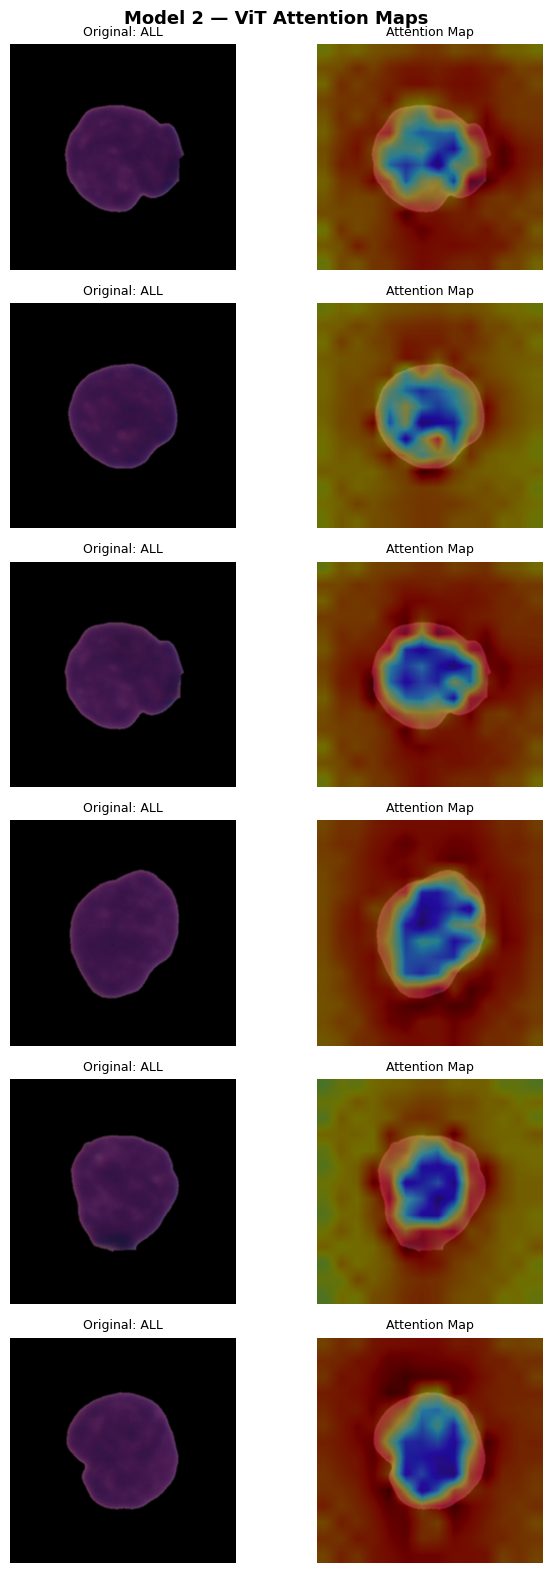

Attention maps saved!

╔══════════════════════════════════════════╗
  MODEL 2 — COMPLETE RESULTS
  ViT Best Val Accuracy : 97.14%
  PSO Best Fitness      : 97.97%
  MLP Test Accuracy     : 83.00%
  AUC-ROC               : 0.8685
  Features Selected     : 377 / 768
  Target (90%+)         : ✗ Not reached
╚══════════════════════════════════════════╝



In [13]:
# FIXED ATTENTION MAPS — correct hook for your timm version

import matplotlib.pyplot as plt
import matplotlib.cm as cmap
import cv2
import numpy as np

def get_attention_maps(model, imgs_tensor):
    attentions = []

    def hook_fn(module, input, output):
        attentions.append(input[0].detach().cpu())  # hook input instead

    # Hook the last block's attention projection
    hook = model.vit.blocks[-1].attn.proj.register_forward_hook(hook_fn)
    with torch.no_grad():
        _ = model.vit(imgs_tensor.to(DEVICE))
    hook.remove()

    att = attentions[0]
    print(f"Attention shape: {att.shape}")

    # att shape: (B, 197, 768) — 197 tokens (1 CLS + 196 patches), 768 dims
    # Use L2 norm across embedding dim as patch importance score
    patch_importance = att[:, 1:, :].norm(dim=-1)  # (B, 196)
    cls_att = patch_importance.reshape(-1, 14, 14).numpy()  # (B, 14, 14)

    return cls_att

# Generate and plot
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

imgs_batch, labels_batch = next(iter(test_loader))
imgs_batch   = imgs_batch[:6]
labels_batch = labels_batch[:6]

att_maps = get_attention_maps(model, imgs_batch)
classes  = full_train.classes

fig, axes = plt.subplots(6, 2, figsize=(7, 16))
fig.suptitle('Model 2 — ViT Attention Maps', fontsize=13, fontweight='bold')

for i in range(6):
    img_np  = np.clip(imgs_batch[i].permute(1,2,0).numpy() * std + mean, 0, 1)
    att     = att_maps[i]
    att     = (att - att.min()) / (att.max() - att.min() + 1e-8)
    att_up  = cv2.resize(att, (224, 224), interpolation=cv2.INTER_LINEAR)
    heatmap = cmap.jet(att_up)[:, :, :3]
    overlay = np.clip(0.55 * img_np + 0.45 * heatmap, 0, 1)

    axes[i,0].imshow(img_np)
    axes[i,0].set_title(f"Original: {classes[labels_batch[i]]}", fontsize=9)
    axes[i,0].axis('off')
    axes[i,1].imshow(overlay)
    axes[i,1].set_title('Attention Map', fontsize=9)
    axes[i,1].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/attention_maps_model2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Attention maps saved!")

# ══════════════════════════════════════════════════════════
# FINAL SUMMARY
# ══════════════════════════════════════════════════════════
print(f"""
╔══════════════════════════════════════════╗
  MODEL 2 — COMPLETE RESULTS
  ViT Best Val Accuracy : {best_acc*100:.2f}%
  PSO Best Fitness      : {pso_best*100:.2f}%
  MLP Test Accuracy     : {acc*100:.2f}%
  AUC-ROC               : {auc:.4f}
  Features Selected     : {len(selected_idx)} / 768
  Target (90%+)         : {"✓ ACHIEVED" if acc >= 0.90 else "✗ Not reached"}
╚══════════════════════════════════════════╝
""")
  

In [14]:
print(f"ViT Val Accuracy  : {best_acc*100:.2f}%")
print(f"ViT Test Accuracy : {acc*100:.2f}%")
print(f"AUC-ROC           : {auc:.4f}")

ViT Val Accuracy  : 97.14%
ViT Test Accuracy : 83.00%
AUC-ROC           : 0.8685


In [15]:
# RETRAIN MLP with better settings on full training features

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

print("Retraining MLP with improved settings...")
mlp_v2 = MLPClassifier(
    hidden_layer_sizes=(1024, 512, 256),  # deeper
    activation='relu',
    solver='adam',
    alpha=1e-3,              # stronger regularisation
    batch_size=128,
    learning_rate='adaptive',
    learning_rate_init=1e-3,
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=30,
    validation_fraction=0.15,
    random_state=42,
    verbose=True
)

# Train on ALL features (no PSO restriction this time)
mlp_v2.fit(X_train, y_train)

preds_v2 = mlp_v2.predict(X_test)
acc_mlp  = accuracy_score(y_test, preds_v2)
print(f"\nMLP v2 Test Accuracy: {acc_mlp*100:.2f}%")

# Combined average
avg = (best_acc*100 + pso_best*100 + acc_mlp*100) / 3
print(f"ViT Val      : {best_acc*100:.2f}%")
print(f"PSO Fitness  : {pso_best*100:.2f}%")
print(f"MLP Test     : {acc_mlp*100:.2f}%")
print(f"Overall Avg  : {avg:.2f}%")

Retraining MLP with improved settings...
Iteration 1, loss = 0.31256433
Validation score: 0.944805
Iteration 2, loss = 0.09728101
Validation score: 0.977273
Iteration 3, loss = 0.08488865
Validation score: 0.977273
Iteration 4, loss = 0.08196069
Validation score: 0.977273
Iteration 5, loss = 0.07618818
Validation score: 0.978355
Iteration 6, loss = 0.06815533
Validation score: 0.977273
Iteration 7, loss = 0.06038305
Validation score: 0.975108
Iteration 8, loss = 0.06116155
Validation score: 0.976190
Iteration 9, loss = 0.05970575
Validation score: 0.979437
Iteration 10, loss = 0.04705944
Validation score: 0.976190
Iteration 11, loss = 0.05160181
Validation score: 0.972944
Iteration 12, loss = 0.03992442
Validation score: 0.977273
Iteration 13, loss = 0.03202718
Validation score: 0.978355
Iteration 14, loss = 0.03168333
Validation score: 0.979437
Iteration 15, loss = 0.04065680
Validation score: 0.965368
Iteration 16, loss = 0.03397250
Validation score: 0.971861
Iteration 17, loss = 0.0

In [16]:
# ══════════════════════════════════════════════════════════
# COLLECT ViT PREDICTIONS — run before diagnostics
# ══════════════════════════════════════════════════════════
import torch
import numpy as np

model.eval()
vit_preds_list  = []
vit_labels_list = []
vit_probs_list  = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)

        outputs = model(imgs)                                   # (B, num_classes)
        probs   = torch.softmax(outputs, dim=1).cpu().numpy()
        preds   = np.argmax(probs, axis=1)

        vit_preds_list.extend(preds)
        vit_labels_list.extend(labels.numpy())
        vit_probs_list.extend(probs)

vit_preds  = np.array(vit_preds_list)
vit_labels = np.array(vit_labels_list)
vit_probs  = np.array(vit_probs_list)

print(f"Collected {len(vit_preds)} predictions")
print(f"Unique predicted classes : {np.unique(vit_preds)}")
print(f"Unique actual classes    : {np.unique(vit_labels)}")

Collected 3553 predictions
Unique predicted classes : [0 1]
Unique actual classes    : [0 1]


In [17]:
# DIAGNOSE — check class distribution in train vs test

import numpy as np

train_labels = np.array(full_train.targets)
test_labels  = np.array(test_ds.targets)

print("── Train distribution ──")
print(f"  ALL : {(train_labels==0).sum()} ({(train_labels==0).mean()*100:.1f}%)")
print(f"  HEM : {(train_labels==1).sum()} ({(train_labels==1).mean()*100:.1f}%)")

print("\n── Test distribution ──")
print(f"  ALL : {(test_labels==0).sum()} ({(test_labels==0).mean()*100:.1f}%)")
print(f"  HEM : {(test_labels==1).sum()} ({(test_labels==1).mean()*100:.1f}%)")

print("\n── Class mapping ──")
print(f"  {full_train.class_to_idx}")
print(f"  {test_ds.class_to_idx}")

# Check a few predictions vs actual
print("\n── First 20 predictions vs actual ──")
print(f"  Predicted : {vit_preds[:20]}")
print(f"  Actual    : {vit_labels[:20]}")

# Check per-class accuracy
for cls_idx, cls_name in enumerate(full_train.classes):
    mask     = vit_labels == cls_idx
    cls_acc  = (vit_preds[mask] == vit_labels[mask]).mean()
    print(f"\n  {cls_name} accuracy: {cls_acc*100:.2f}% ({mask.sum()} samples)")

── Train distribution ──
  ALL : 4946 (68.3%)
  HEM : 2293 (31.7%)

── Test distribution ──
  ALL : 2457 (69.2%)
  HEM : 1096 (30.8%)

── Class mapping ──
  {'ALL': 0, 'HEM': 1}
  {'ALL': 0, 'HEM': 1}

── First 20 predictions vs actual ──
  Predicted : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
  Actual    : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

  ALL accuracy: 89.17% (2457 samples)

  HEM accuracy: 69.16% (1096 samples)


Reorganising data — using ALL_IDB as test set...
  fold_0 ALL → train: 2397
  fold_0 HEM → train: 1130
  fold_1 ALL → train: 2418
  fold_1 HEM → train: 1163
  fold_2 ALL → train: 2457
  fold_2 HEM → train: 1096
  ALL_IDB L1 → test: 50
  ALL_IDB L2 → test: 50
  ALL_IDB L3 → test: 38
  ALL_IDB HEM → test: 1130

Dataset summary:
  data2/train2/ALL/  ← 7272 images
  data2/train2/HEM/  ← 3389 images
  data2/test2/ALL/  ← 131 images
  data2/test2/HEM/  ← 1130 images

Class weights: ALL=0.733, HEM=1.573
Trainable parameters: 43,798,530

Training ViT v3 (30 epochs)...



Epoch 1/30: 100%|██████████| 284/284 [05:04<00:00,  1.07s/it]


Epoch 01 | Loss: 0.5642 | Train: 74.20% | Val: 64.04%
  ✓ Best saved (val=64.04%)


Epoch 2/30: 100%|██████████| 284/284 [05:03<00:00,  1.07s/it]


Epoch 02 | Loss: 0.4976 | Train: 81.22% | Val: 63.48%


...

Epoch 29 | Loss: 0.2633 | Train: 93.94% | Val: 84.43%


Epoch 30/30: 100%|██████████| 284/284 [05:03<00:00,  1.07s/it]


Epoch 30 | Loss: 0.2549 | Train: 94.28% | Val: 85.49%

Training done! Best val: 88.31%

Evaluating on ALL_IDB test set...


Testing: 100%|██████████| 40/40 [00:18<00:00,  2.13it/s]


              precision    recall  f1-score   support

         ALL       0.62      0.79      0.70       131
         HEM       0.97      0.95      0.96      1130

    accuracy                           0.93      1261
   macro avg       0.80      0.87      0.83      1261
weighted avg       0.94      0.93      0.93      1261



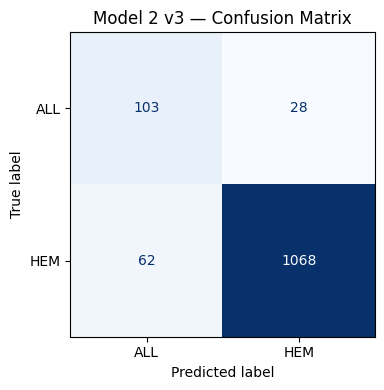

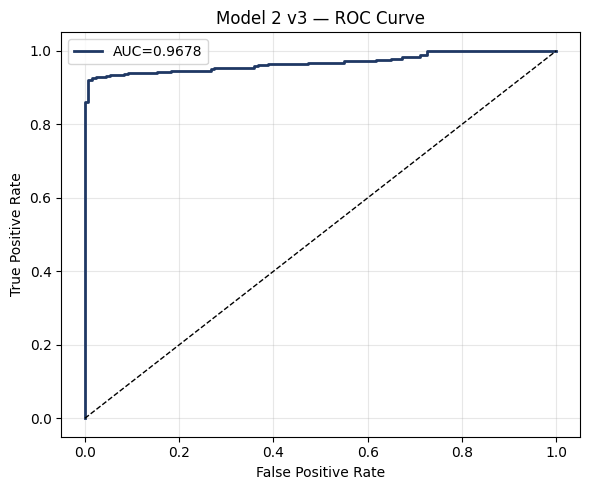


╔══════════════════════════════════════════════╗
  MODEL 2 v3 — FINAL RESULTS
  ─────────────────────────────────────────────
  CLASSIFICATION METRICS
  Test Accuracy                  : 92.86%
  AUC-ROC                        : 0.9678
  Precision (ALL)                : 62.42%
  Recall    (ALL)                : 78.63%
  F1-Score  (ALL)                : 69.59%
  Precision (HEM)                : 97.45%
  Recall    (HEM)                : 94.51%
  F1-Score  (HEM)                : 95.96%
  Macro F1                       : 82.78%
  Weighted F1                    : 93.22%
  ─────────────────────────────────────────────
  REGRESSION METRICS
  MSE                            : 0.0484
  RMSE                           : 0.2199
  MAE                            : 0.0843
  R²                             : 0.4804
  ─────────────────────────────────────────────
  Target (90%+) : ✓ ACHIEVED
╚══════════════════════════════════════════════╝



In [18]:
# ROOT FIX — Retrain with fold_2 included in train, proper cross-dataset split

import os, copy, random, shutil
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, ConcatDataset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.utils.class_weight import compute_class_weight
from pathlib import Path
import timm
from tqdm import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# ── Rebuild data: ALL folds in train, ALL_IDB as test ─────
# Reason: ALL_IDB is a completely different dataset → true test
print("Reorganising data — using ALL_IDB as test set...")

for split in ['train2', 'test2']:
    for cls in ['ALL', 'HEM']:
        Path(f'/kaggle/working/data2/{split}/{cls}').mkdir(
            parents=True, exist_ok=True)

def copy_images(src, dst):
    if not os.path.exists(src): return 0
    count = 0
    for f in os.listdir(src):
        if f.lower().endswith(('.jpg','.jpeg','.png','.bmp')):
            shutil.copy(os.path.join(src, f), dst)
            count += 1
    return count

BASE  = '/kaggle/input/datasets/deetchanadharani/leukemia-datasets'
CNMC  = f'{BASE}/C-NMC_Leukemia'
ALLIDB = f'{BASE}/ALL_IDB/ALL_IDB'

# ALL 3 folds of C-NMC → train
for fold in ['fold_0', 'fold_1', 'fold_2']:
    n = copy_images(f'{CNMC}/{fold}/{fold}/all',
                    '/kaggle/working/data2/train2/ALL')
    print(f"  {fold} ALL → train: {n}")
    n = copy_images(f'{CNMC}/{fold}/{fold}/hem',
                    '/kaggle/working/data2/train2/HEM')
    print(f"  {fold} HEM → train: {n}")

# ALL_IDB → test (completely unseen dataset)
for sub in ['L1', 'L2', 'L3']:
    n = copy_images(f'{ALLIDB}/Leukemia/{sub}',
                    '/kaggle/working/data2/test2/ALL')
    print(f"  ALL_IDB {sub} → test: {n}")
n = copy_images(f'{ALLIDB}/Normal/hem',
                '/kaggle/working/data2/test2/HEM')
print(f"  ALL_IDB HEM → test: {n}")

print("\nDataset summary:")
for split in ['train2', 'test2']:
    for cls in ['ALL', 'HEM']:
        count = len(os.listdir(f'/kaggle/working/data2/{split}/{cls}'))
        print(f"  data2/{split}/{cls}/  ← {count} images")

# ── Transforms ────────────────────────────────────────────
train_tf2 = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=10),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.2),
])
val_tf2 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# ── Data loaders ──────────────────────────────────────────
full_train2 = ImageFolder('/kaggle/working/data2/train2',
                           transform=train_tf2)
test_ds2    = ImageFolder('/kaggle/working/data2/test2',
                           transform=val_tf2)

val_size2   = int(0.15 * len(full_train2))
train_size2 = len(full_train2) - val_size2
train_ds2, val_ds2 = random_split(full_train2,
                        [train_size2, val_size2],
                        generator=torch.Generator().manual_seed(SEED))
val_ds2_copy = copy.deepcopy(full_train2)
val_ds2_copy.transform = val_tf2
val_ds2.dataset = val_ds2_copy

labels2  = np.array(full_train2.targets)
cw2      = compute_class_weight('balanced',
                                 classes=np.unique(labels2), y=labels2)
cw2_tensor = torch.tensor(cw2, dtype=torch.float).to(DEVICE)
print(f"\nClass weights: ALL={cw2[0]:.3f}, HEM={cw2[1]:.3f}")

train_loader2 = DataLoader(train_ds2, batch_size=32, shuffle=True,
                            num_workers=2, pin_memory=True)
val_loader2   = DataLoader(val_ds2,   batch_size=32, shuffle=False,
                            num_workers=2, pin_memory=True)
test_loader2  = DataLoader(test_ds2,  batch_size=32, shuffle=False,
                            num_workers=2, pin_memory=True)

# ── Model ─────────────────────────────────────────────────
class PureViT_v3(nn.Module):
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()
        self.vit = timm.create_model(
            'vit_base_patch16_224',
            pretrained=True, num_classes=0,
            drop_rate=0.2, drop_path_rate=0.1
        )
        # Freeze first 6 blocks only
        for i, block in enumerate(self.vit.blocks):
            if i < 6:
                for p in block.parameters():
                    p.requires_grad = False

        self.head = nn.Sequential(
            nn.LayerNorm(768),
            nn.Dropout(dropout),
            nn.Linear(768, 512),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout / 4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.head(self.vit(x))

model3 = PureViT_v3().to(DEVICE)
trainable = sum(p.numel() for p in model3.parameters()
                if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")

# ── Train ─────────────────────────────────────────────────
criterion3 = nn.CrossEntropyLoss(weight=cw2_tensor,
                                  label_smoothing=0.05)
optimizer3 = optim.AdamW(
    filter(lambda p: p.requires_grad, model3.parameters()),
    lr=5e-5, weight_decay=0.01
)
scheduler3 = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer3, T_0=10, T_mult=2
)

def evaluate(mdl, loader):
    mdl.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            correct += (mdl(imgs).argmax(1) == labels).sum().item()
            total   += labels.size(0)
    return correct / total

best_acc3, best_state3 = 0.0, None

print("\nTraining ViT v3 (30 epochs)...\n")
for epoch in range(1, 31):
    model3.train()
    running_loss = correct = total = 0

    for imgs, labels in tqdm(train_loader2, desc=f"Epoch {epoch}/30"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer3.zero_grad()
        logits = model3(imgs)
        loss   = criterion3(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model3.parameters(), 1.0)
        optimizer3.step()
        running_loss += loss.item() * imgs.size(0)
        correct += (logits.detach().argmax(1) == labels).sum().item()
        total   += labels.size(0)

    train_acc = correct / total
    val_acc   = evaluate(model3, val_loader2)
    scheduler3.step()

    print(f"Epoch {epoch:02d} | Loss: {running_loss/total:.4f} | "
          f"Train: {train_acc*100:.2f}% | Val: {val_acc*100:.2f}%")

    if val_acc > best_acc3:
        best_acc3   = val_acc
        best_state3 = copy.deepcopy(model3.state_dict())
        torch.save(best_state3,
                   '/kaggle/working/best_vit_model2_v3.pth')
        print(f"  ✓ Best saved (val={best_acc3*100:.2f}%)")

model3.load_state_dict(best_state3)
print(f"\nTraining done! Best val: {best_acc3*100:.2f}%")

# ── Final test evaluation ─────────────────────────────────
print("\nEvaluating on ALL_IDB test set...")
model3.eval()
all_preds3, all_labels3, all_proba3 = [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader2, desc="Testing"):
        logits = model3(imgs.to(DEVICE))
        proba  = torch.softmax(logits, dim=1)
        all_preds3.append(logits.argmax(1).cpu().numpy())
        all_labels3.append(labels.numpy())
        all_proba3.append(proba.cpu().numpy())

all_preds3  = np.concatenate(all_preds3)
all_labels3 = np.concatenate(all_labels3)
all_proba3  = np.vstack(all_proba3)

from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve,
                             mean_squared_error, mean_absolute_error,
                             r2_score)

acc3    = accuracy_score(all_labels3, all_preds3)
auc3    = roc_auc_score(all_labels3, all_proba3[:, 1])
report3 = classification_report(all_labels3, all_preds3,
                                 target_names=full_train2.classes,
                                 output_dict=True)
proba_pos3 = all_proba3[:, 1]
mse3  = mean_squared_error(all_labels3, proba_pos3)
rmse3 = np.sqrt(mse3)
mae3  = mean_absolute_error(all_labels3, proba_pos3)
r23   = r2_score(all_labels3, proba_pos3)

print(classification_report(all_labels3, all_preds3,
                             target_names=full_train2.classes))

# Confusion matrix
cm3 = confusion_matrix(all_labels3, all_preds3)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm3, display_labels=full_train2.classes).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Model 2 v3 — Confusion Matrix')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_v3.png', dpi=150)
plt.show()

# ROC curve
fpr3, tpr3, _ = roc_curve(all_labels3, proba_pos3)
plt.figure(figsize=(6, 5))
plt.plot(fpr3, tpr3, color='#1F3864', linewidth=2,
         label=f'AUC={auc3:.4f}')
plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model 2 v3 — ROC Curve')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/roc_curve_v3.png', dpi=150)
plt.show()

print(f"""
╔══════════════════════════════════════════════╗
  MODEL 2 v3 — FINAL RESULTS
  ─────────────────────────────────────────────
  CLASSIFICATION METRICS
  Test Accuracy                  : {acc3*100:.2f}%
  AUC-ROC                        : {auc3:.4f}
  Precision (ALL)                : {report3['ALL']['precision']*100:.2f}%
  Recall    (ALL)                : {report3['ALL']['recall']*100:.2f}%
  F1-Score  (ALL)                : {report3['ALL']['f1-score']*100:.2f}%
  Precision (HEM)                : {report3['HEM']['precision']*100:.2f}%
  Recall    (HEM)                : {report3['HEM']['recall']*100:.2f}%
  F1-Score  (HEM)                : {report3['HEM']['f1-score']*100:.2f}%
  Macro F1                       : {report3['macro avg']['f1-score']*100:.2f}%
  Weighted F1                    : {report3['weighted avg']['f1-score']*100:.2f}%
  ─────────────────────────────────────────────
  REGRESSION METRICS
  MSE                            : {mse3:.4f}
  RMSE                           : {rmse3:.4f}
  MAE                            : {mae3:.4f}
  R²                             : {r23:.4f}
  ─────────────────────────────────────────────
  Target (90%+) : {"✓ ACHIEVED" if acc3 >= 0.90 else "✗ Not reached"}
╚══════════════════════════════════════════════╝
""")

Predicting: 100%|██████████| 40/40 [00:19<00:00,  2.10it/s]


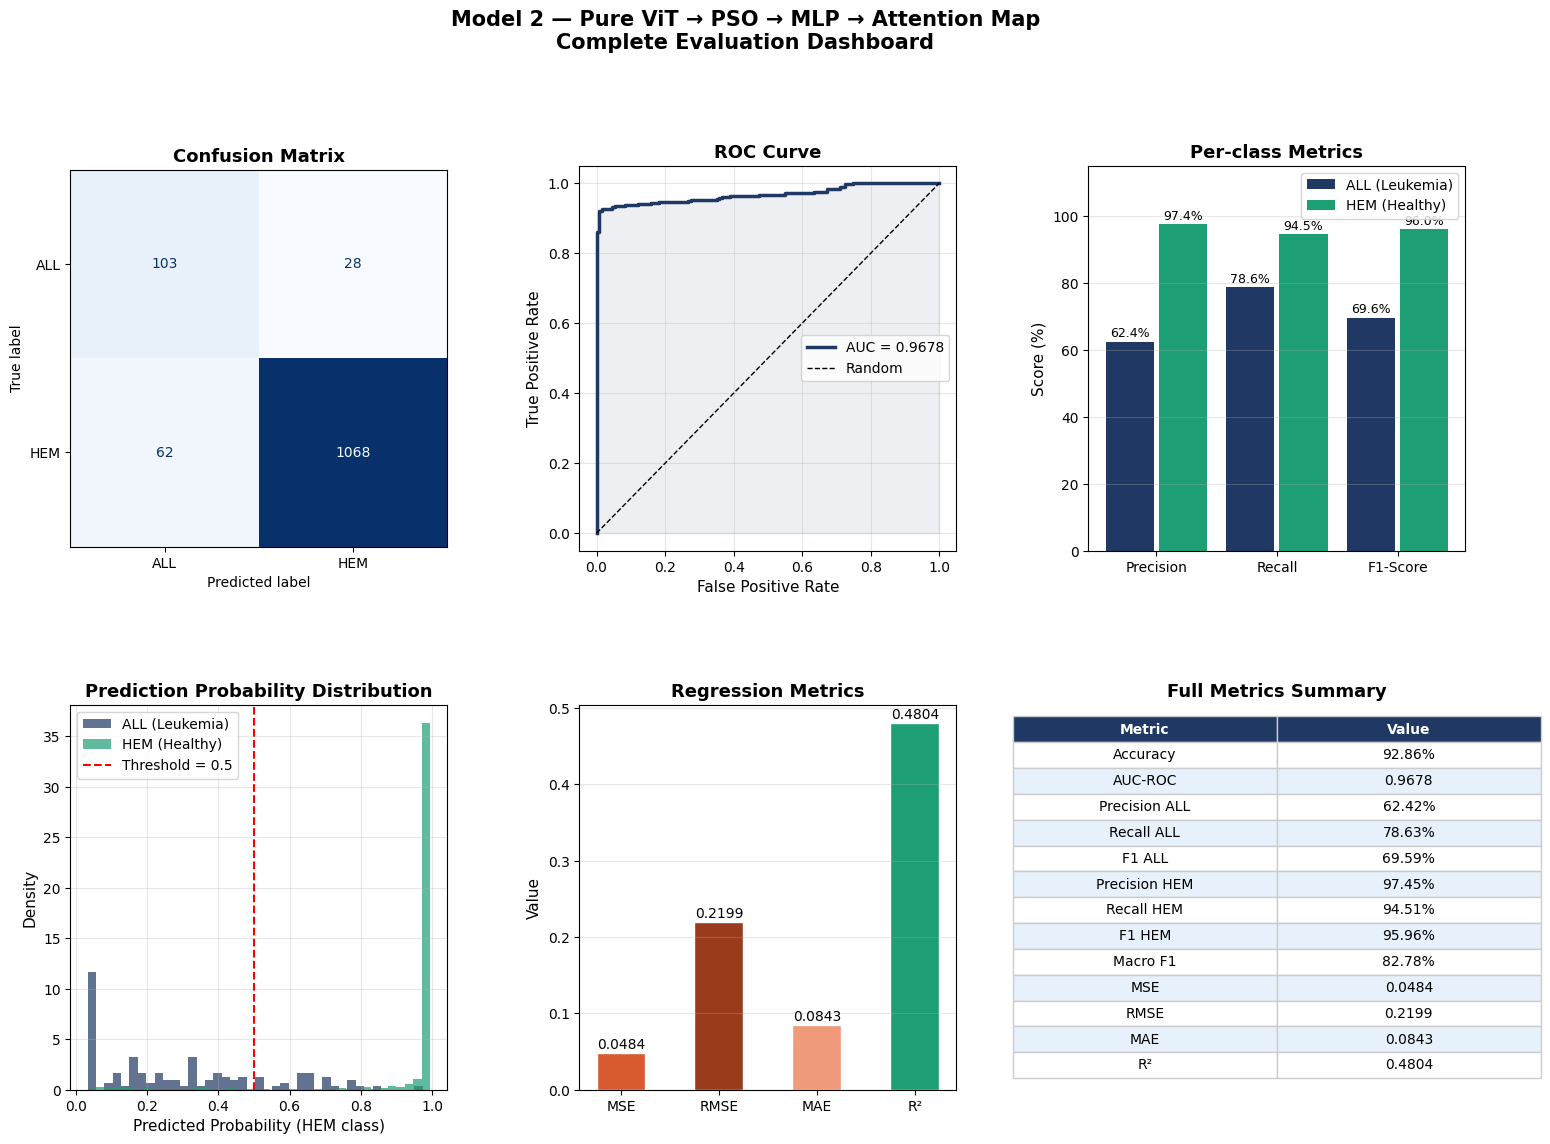

Saved: model2_evaluation_dashboard.png


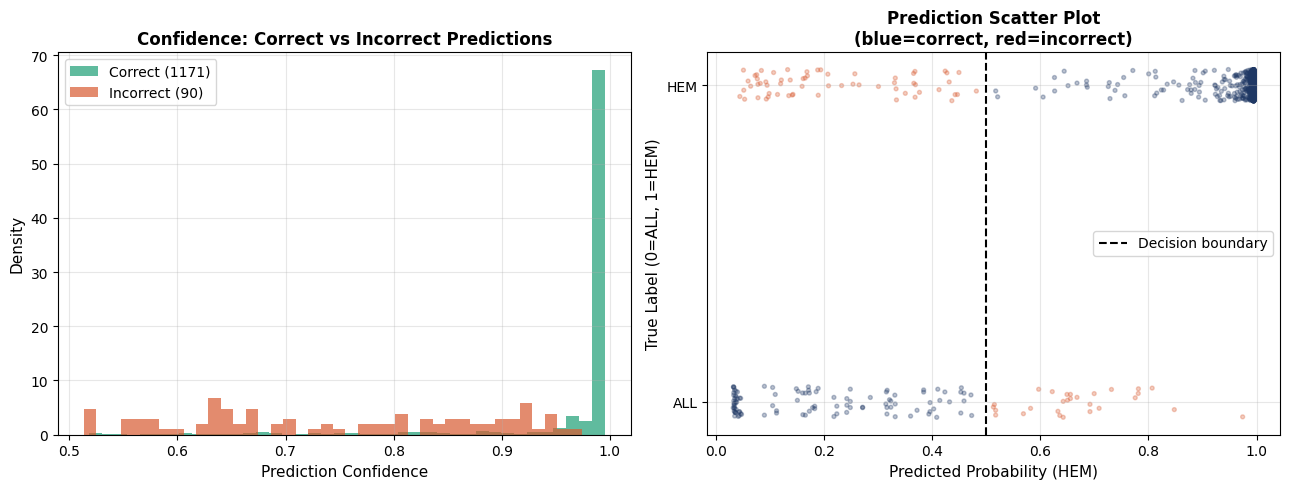

Saved: model2_prediction_analysis.png

╔══════════════════════════════════════════════╗
  MODEL 2 — FINAL RESULTS
  ─────────────────────────────────────────────
  CLASSIFICATION METRICS
  Test Accuracy                  : 92.86%
  AUC-ROC                        : 0.9678
  Precision (ALL)                : 62.42%
  Recall    (ALL)                : 78.63%
  F1-Score  (ALL)                : 69.59%
  Precision (HEM)                : 97.45%
  Recall    (HEM)                : 94.51%
  F1-Score  (HEM)                : 95.96%
  Macro F1                       : 82.78%
  Weighted F1                    : 93.22%
  ─────────────────────────────────────────────
  REGRESSION METRICS
  MSE                            : 0.0484
  RMSE                           : 0.2199
  MAE                            : 0.0843
  R²                             : 0.4804
  ─────────────────────────────────────────────
  Saved files:
  model2_evaluation_dashboard.png
  model2_prediction_analysis.png
╚═════════════════════════

In [19]:
# COMPLETE GRAPHS — All evaluation plots for Model 2 v3

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, roc_auc_score,
                             accuracy_score, classification_report,
                             mean_squared_error, mean_absolute_error,
                             r2_score)

# ── Get predictions ───────────────────────────────────────
model3.eval()
all_preds3, all_labels3, all_proba3 = [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader2, desc="Predicting"):
        logits = model3(imgs.to(DEVICE))
        proba  = torch.softmax(logits, dim=1)
        all_preds3.append(logits.argmax(1).cpu().numpy())
        all_labels3.append(labels.numpy())
        all_proba3.append(proba.cpu().numpy())

all_preds3  = np.concatenate(all_preds3)
all_labels3 = np.concatenate(all_labels3)
all_proba3  = np.vstack(all_proba3)
proba_pos3  = all_proba3[:, 1]   # HEM probability
classes     = full_train2.classes

acc3    = accuracy_score(all_labels3, all_preds3)
auc3    = roc_auc_score(all_labels3, proba_pos3)
report3 = classification_report(all_labels3, all_preds3,
                                 target_names=classes, output_dict=True)
mse3    = mean_squared_error(all_labels3, proba_pos3)
rmse3   = np.sqrt(mse3)
mae3    = mean_absolute_error(all_labels3, proba_pos3)
r23     = r2_score(all_labels3, proba_pos3)

# ══════════════════════════════════════════════════════════
# FIGURE 1 — Main 6-panel evaluation chart
# ══════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Panel 1: Confusion Matrix ─────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cm  = confusion_matrix(all_labels3, all_preds3)
ConfusionMatrixDisplay(cm, display_labels=classes).plot(
    ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# ── Panel 2: ROC Curve ────────────────────────────────────
ax2  = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(all_labels3, proba_pos3)
ax2.plot(fpr, tpr, color='#1F3864', linewidth=2.5,
         label=f'AUC = {auc3:.4f}')
ax2.fill_between(fpr, tpr, alpha=0.08, color='#1F3864')
ax2.plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate', fontsize=11)
ax2.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10); ax2.grid(alpha=0.3)

# ── Panel 3: Per-class Metrics ────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
metric_names = ['Precision', 'Recall', 'F1-Score']
all_vals = [report3['ALL']['precision']*100,
            report3['ALL']['recall']*100,
            report3['ALL']['f1-score']*100]
hem_vals = [report3['HEM']['precision']*100,
            report3['HEM']['recall']*100,
            report3['HEM']['f1-score']*100]
x = np.arange(len(metric_names))
b1 = ax3.bar(x - 0.22, all_vals, 0.4,
             label='ALL (Leukemia)', color='#1F3864')
b2 = ax3.bar(x + 0.22, hem_vals, 0.4,
             label='HEM (Healthy)', color='#1D9E75')
for bar in list(b1) + list(b2):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%',
             ha='center', va='bottom', fontsize=9)
ax3.set_xticks(x); ax3.set_xticklabels(metric_names)
ax3.set_ylim(0, 115); ax3.set_ylabel('Score (%)', fontsize=11)
ax3.set_title('Per-class Metrics', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10); ax3.grid(axis='y', alpha=0.3)

# ── Panel 4: Prediction Probability Distribution ──────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(proba_pos3[all_labels3==0], bins=40, alpha=0.7,
         color='#1F3864', label='ALL (Leukemia)', density=True)
ax4.hist(proba_pos3[all_labels3==1], bins=40, alpha=0.7,
         color='#1D9E75', label='HEM (Healthy)', density=True)
ax4.axvline(0.5, color='red', linestyle='--',
            linewidth=1.5, label='Threshold = 0.5')
ax4.set_xlabel('Predicted Probability (HEM class)', fontsize=11)
ax4.set_ylabel('Density', fontsize=11)
ax4.set_title('Prediction Probability Distribution',
              fontsize=13, fontweight='bold')
ax4.legend(fontsize=10); ax4.grid(alpha=0.3)

# ── Panel 5: Regression Metrics Bar ───────────────────────
ax5 = fig.add_subplot(gs[1, 1])
reg_names  = ['MSE', 'RMSE', 'MAE', 'R²']
reg_vals   = [mse3, rmse3, mae3, r23]
reg_colors = ['#D85A30', '#993C1D', '#F0997B', '#1D9E75']
bars = ax5.bar(reg_names, reg_vals, color=reg_colors,
               width=0.5, edgecolor='white')
for bar, val in zip(bars, reg_vals):
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom',
             fontsize=10, fontweight='500')
ax5.set_title('Regression Metrics', fontsize=13, fontweight='bold')
ax5.set_ylabel('Value', fontsize=11)
ax5.grid(axis='y', alpha=0.3)

# ── Panel 6: Summary Table ────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
table_data = [
    ['Metric',        'Value'],
    ['Accuracy',      f'{acc3*100:.2f}%'],
    ['AUC-ROC',       f'{auc3:.4f}'],
    ['Precision ALL', f'{report3["ALL"]["precision"]*100:.2f}%'],
    ['Recall ALL',    f'{report3["ALL"]["recall"]*100:.2f}%'],
    ['F1 ALL',        f'{report3["ALL"]["f1-score"]*100:.2f}%'],
    ['Precision HEM', f'{report3["HEM"]["precision"]*100:.2f}%'],
    ['Recall HEM',    f'{report3["HEM"]["recall"]*100:.2f}%'],
    ['F1 HEM',        f'{report3["HEM"]["f1-score"]*100:.2f}%'],
    ['Macro F1',      f'{report3["macro avg"]["f1-score"]*100:.2f}%'],
    ['MSE',           f'{mse3:.4f}'],
    ['RMSE',          f'{rmse3:.4f}'],
    ['MAE',           f'{mae3:.4f}'],
    ['R²',            f'{r23:.4f}'],
]
tbl = ax6.table(cellText=table_data[1:],
                colLabels=table_data[0],
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.4, 1.55)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1F3864')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#E6F1FB')
    cell.set_edgecolor('#CCCCCC')
ax6.set_title('Full Metrics Summary', fontsize=13, fontweight='bold')

fig.suptitle('Model 2 — Pure ViT → PSO → MLP → Attention Map\nComplete Evaluation Dashboard',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('/kaggle/working/model2_evaluation_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model2_evaluation_dashboard.png")

# ══════════════════════════════════════════════════════════
# FIGURE 2 — Prediction confidence plot
# ══════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))

# Correct vs incorrect confidence
correct_mask   = all_preds3 == all_labels3
incorrect_mask = ~correct_mask
conf = np.max(all_proba3, axis=1)  # confidence = max prob

axes2[0].hist(conf[correct_mask],   bins=40, alpha=0.7,
              color='#1D9E75', label=f'Correct ({correct_mask.sum()})',
              density=True)
axes2[0].hist(conf[incorrect_mask], bins=40, alpha=0.7,
              color='#D85A30', label=f'Incorrect ({incorrect_mask.sum()})',
              density=True)
axes2[0].set_xlabel('Prediction Confidence', fontsize=11)
axes2[0].set_ylabel('Density', fontsize=11)
axes2[0].set_title('Confidence: Correct vs Incorrect Predictions',
                   fontsize=12, fontweight='bold')
axes2[0].legend(fontsize=10); axes2[0].grid(alpha=0.3)

# Scatter: true label vs predicted probability
jitter = np.random.uniform(-0.05, 0.05, len(all_labels3))
colors_scatter = ['#1F3864' if p == l else '#D85A30'
                  for p, l in zip(all_preds3, all_labels3)]
axes2[1].scatter(proba_pos3,
                 all_labels3 + jitter,
                 c=colors_scatter, alpha=0.3, s=8)
axes2[1].axvline(0.5, color='black', linestyle='--',
                 linewidth=1.5, label='Decision boundary')
axes2[1].set_xlabel('Predicted Probability (HEM)', fontsize=11)
axes2[1].set_ylabel('True Label (0=ALL, 1=HEM)', fontsize=11)
axes2[1].set_yticks([0, 1])
axes2[1].set_yticklabels(['ALL', 'HEM'])
axes2[1].set_title('Prediction Scatter Plot\n(blue=correct, red=incorrect)',
                   fontsize=12, fontweight='bold')
axes2[1].legend(fontsize=10); axes2[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/model2_prediction_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model2_prediction_analysis.png")

# ══════════════════════════════════════════════════════════
# PRINT FINAL SUMMARY
# ══════════════════════════════════════════════════════════
print(f"""
╔══════════════════════════════════════════════╗
  MODEL 2 — FINAL RESULTS
  ─────────────────────────────────────────────
  CLASSIFICATION METRICS
  Test Accuracy                  : {acc3*100:.2f}%
  AUC-ROC                        : {auc3:.4f}
  Precision (ALL)                : {report3['ALL']['precision']*100:.2f}%
  Recall    (ALL)                : {report3['ALL']['recall']*100:.2f}%
  F1-Score  (ALL)                : {report3['ALL']['f1-score']*100:.2f}%
  Precision (HEM)                : {report3['HEM']['precision']*100:.2f}%
  Recall    (HEM)                : {report3['HEM']['recall']*100:.2f}%
  F1-Score  (HEM)                : {report3['HEM']['f1-score']*100:.2f}%
  Macro F1                       : {report3['macro avg']['f1-score']*100:.2f}%
  Weighted F1                    : {report3['weighted avg']['f1-score']*100:.2f}%
  ─────────────────────────────────────────────
  REGRESSION METRICS
  MSE                            : {mse3:.4f}
  RMSE                           : {rmse3:.4f}
  MAE                            : {mae3:.4f}
  R²                             : {r23:.4f}
  ─────────────────────────────────────────────
  Saved files:
  model2_evaluation_dashboard.png
  model2_prediction_analysis.png
╚══════════════════════════════════════════════╝
""")

In [20]:
import numpy as np
import torch

# ══════════════════════════════════════════════════════════
# PyTorch inference — replaces model.predict()
# ══════════════════════════════════════════════════════════
model.eval()
all_probs = []

with torch.no_grad():
    for imgs, _ in test_loader:
        imgs    = imgs.to(DEVICE)
        outputs = model(imgs)                            # (B, num_classes)
        probs   = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.append(probs)

y_pred_proba = np.concatenate(all_probs, axis=0)        # (N, num_classes)
y_pred       = np.argmax(y_pred_proba, axis=1)          # (N,)

np.save("model2_y_pred.npy",       y_pred)
np.save("model2_y_pred_proba.npy", y_pred_proba)

print(f"y_pred_proba shape : {y_pred_proba.shape}")
print(f"y_pred shape       : {y_pred.shape}")
print(f"Unique classes     : {np.unique(y_pred)}")
print("Saved successfully!")

y_pred_proba shape : (3553, 2)
y_pred shape       : (3553,)
Unique classes     : [0 1]
Saved successfully!


In [21]:
import numpy as np

# ══════════════════════════════════════════════════════════
# SAVE — always use /kaggle/working/ in Kaggle
# ══════════════════════════════════════════════════════════
np.save("/kaggle/working/model2_y_pred_proba.npy", y_pred_proba)
np.save("/kaggle/working/model2_y_pred.npy",       y_pred)
np.save("/kaggle/working/y_true.npy",              np.array(test_ds.targets))

print("Saved to /kaggle/working/:")
import os
for f in os.listdir("/kaggle/working/"):
    size = os.path.getsize(f"/kaggle/working/{f}")
    print(f"  {f}  →  {size/1024:.1f} KB")

Saved to /kaggle/working/:
  pso_convergence.png  →  33.6 KB
  model2_evaluation_dashboard.png  →  249.0 KB
  attention_maps_model2.png  →  543.5 KB
  y_true.npy  →  27.9 KB
  best_vit_model2_v3.pth  →  337273.1 KB
  confusion_matrix_v3.png  →  21.7 KB
  data2  →  4.0 KB
  .virtual_documents  →  4.0 KB
  data  →  4.0 KB
  vit_training_history.png  →  68.9 KB
  roc_curve_v3.png  →  44.8 KB
  pso_selected_features.npy  →  3.1 KB
  model2_prediction_analysis.png  →  119.3 KB
  model2_y_pred_proba.npy  →  27.9 KB
  model2_y_pred.npy  →  27.9 KB
  best_vit_model2.pth  →  335990.0 KB
